# Netflix Project 

In [66]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [68]:
netflix_df = pd.read_csv("netflix raw.csv")
# netflix_df.head()

# cleaning the data 
# print (f"{netflix_df.info()}")
# print (f"{netflix_df.describe()}")

# checking the null values per column in the data set 
print (f"Null values per column in the data set \n\n{netflix_df.isnull().sum()}")

# filling with unknown values
netflix_df['director'].fillna('unknown',inplace=True)
netflix_df['cast'].fillna('unknown',inplace=True)
netflix_df['country'].fillna('unknown',inplace=True)

#converting the string type fo the date_added column to the datetime of the pandas 
netflix_df['date_added']=pd.to_datetime(netflix_df['date_added'], errors='coerce')
netflix_df['date_added'].interpolate(method='linear',axis=0, inplace=True)

# filling with the average values
missing_rating = netflix_df[netflix_df['rating'].isnull()]   # for finding the missing values in the rows of the specific column 
# print (missing_rating)

netflix_df["rating"].fillna( "TV-MA",inplace=True)
netflix_df['duration'].fillna('90 min',inplace=True)
print (f"Null values per column in the data set \n\n{netflix_df.isnull().sum()}")

# netflix_df.to_csv('cleaned_netflix_data.csv')


Null values per column in the data set 

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64
Null values per column in the data set 

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


C:\Users\izaza\AppData\Local\Temp\ipykernel_4632\428440378.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  netflix_df['director'].fillna('unknown',inplace=True)
C:\Users\izaza\AppData\Local\Temp\ipykernel_4632\428440378.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

### now taking an insights from it 

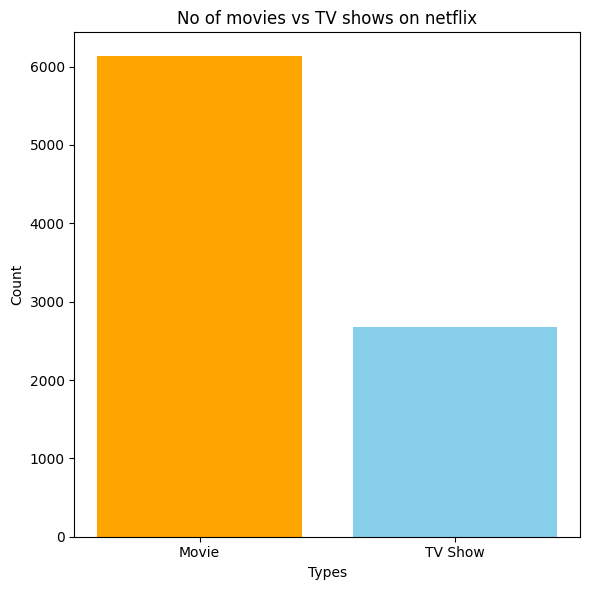

In [36]:
# ploting the bar chart 
counts = netflix_df['type'].value_counts()
plt.figure(figsize=(6,6))
plt.bar(counts.index , counts.values , color= ['orange','skyblue'],label='Movies vs TV show')
plt.title("No of movies vs TV shows on netflix")
plt.xlabel('Types')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movies_vs_tvshows.png')
plt.show()

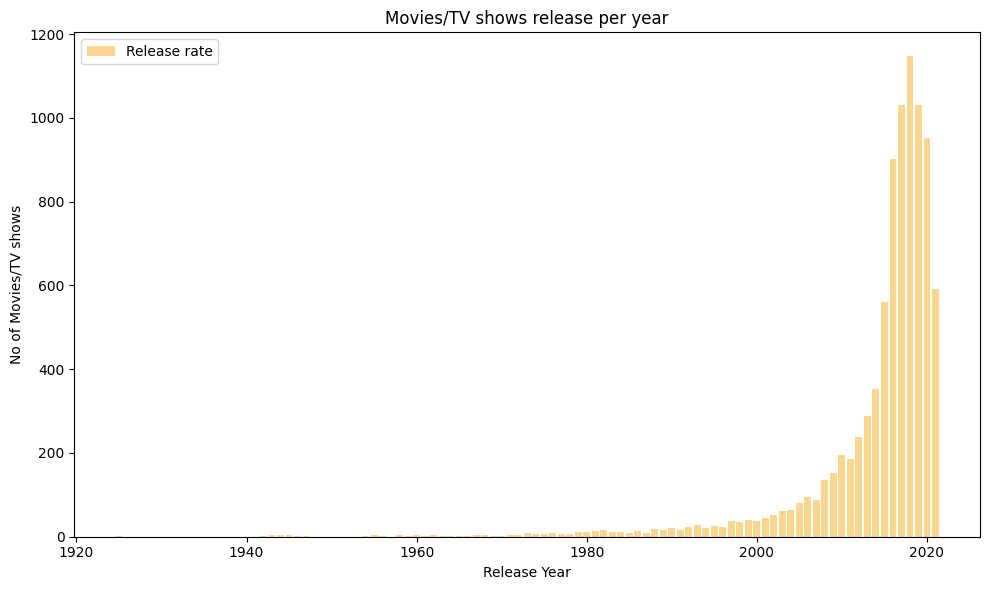

In [64]:
# Content trend over time → Number of shows/movies released per year (Line chart / Bar chart)
release_counts = netflix_df['release_year'].value_counts()
plt.figure(figsize=(10,6))
plt.bar(release_counts.index, release_counts.values, color=['#FAD691'],label="Release rate")
plt.title("Movies/TV shows release per year")
plt.xlabel("Release Year")
plt.ylabel("No of Movies/TV shows")
plt.legend()
# plt.grid()
plt.tight_layout()
# plt.savefig("Release_rate.png")
plt.show ()

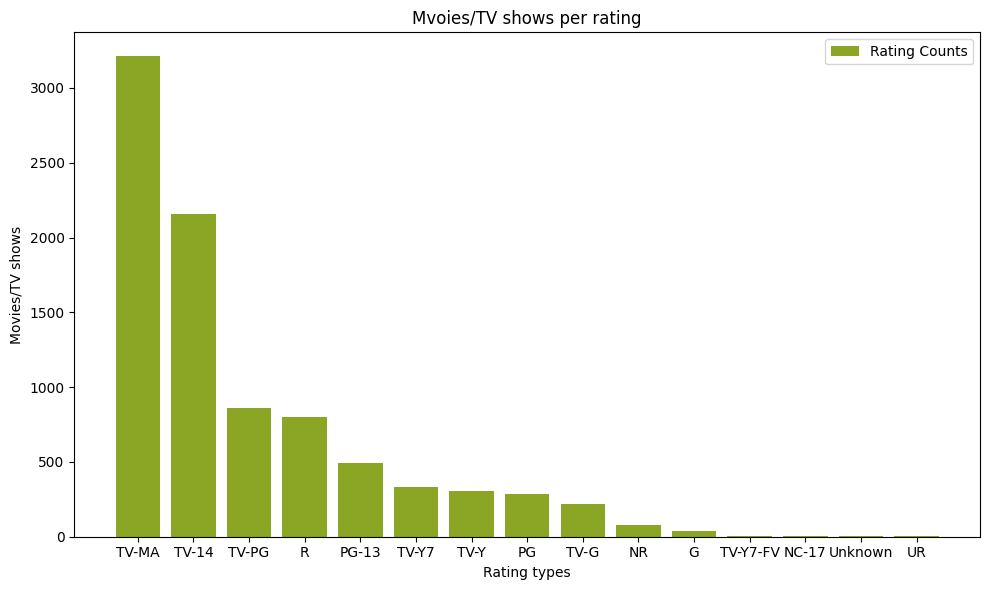

In [71]:
# Most common ratings → Distribution of ratings like TV-MA, PG-13 using pie chart 
valid_ratings = {
    "PG-13","TV-MA","PG","TV-14","TV-PG","TV-Y","TV-Y7","R",
    "TV-G","G","NC-17","NR","TV-Y7-FV","UR"
}

pattern = r'^\s*\d+\s*(?:min(s)?|m|season(s)?)\s*$'

# Step A: Replace wrong ratings (like "74 min") with NaN
mask = netflix_df['rating'].str.fullmatch(pattern, na=False, case=False)
netflix_df.loc[mask, 'rating'] = pd.NA

# Step B: Replace anything not in valid ratings list with "Unknown"
netflix_df['rating'] = netflix_df['rating'].where(netflix_df['rating'].isin(valid_ratings), "Unknown")
# netflix_df.to_csv('cleaned_netflix_data.csv')

# rating_types= netflix_df['rating'].unique()   # this tell us about the unique types in the rating columns 
# print (rating_types)

rating_counts = netflix_df['rating'].value_counts()
plt.figure(figsize=(10,6))
plt.bar(rating_counts.index, rating_counts.values, color='#8AA624',label='Rating Counts')
plt.title('Mvoies/TV shows per rating')
plt.xlabel('Rating types')
plt.ylabel("Movies/TV shows")
plt.legend()
plt.tight_layout()
plt.savefig('Rating_counts.png')
plt.show()


finding average duration for movies and average seasons for tv shows , the data in the column is not a numeric so we can apply the mean () function of the numpy directly so we have to convert it into a numeric data,  

In [ ]:
# splitting the column into movies datafram and shows data fram 
movies_df = netflix_df[netflix_df['type']=='Movie']
TV_shows_df = netflix_df[netflix_df['type']== "TV Show"]


movies_df['duration'] = movies_df['duration'].str.replace(' min','').astype(float) 
TV_shows_df['duration'] = TV_shows_df['duration'].str.replace(' Seasons', '').str.replace(' Season','').astype(float)    # can't take the list or tuple so it has to pass in the reges patteren  or mention separately
average_duration = np.mean(movies_df['duration'])
average_season = np.mean (TV_shows_df['duration'])

print (f"The average duration of movies : {average_duration}")
print (f"\nThe average seasons of TV show : {average_season}")

# duration= open ('Average_duration.txt', 'w' )
# duration.write(f"The average duration of movies : {average_duration} minutes") 
# duration.write(f"\nThe average seasons of TV show : {average_season} seasons")


from docx import Document       # to save the report as docx file 
doc = Document()
doc.add_heading("Average Duration Report")   # the heading of the file  
doc.add_paragraph(f"\nThe average seasons of TV show : {average_season} seasons")   # the data added 
doc.add_paragraph(f"The average duration of movies : {average_duration} minutes")
doc.save('duration report.docx')  # saving the file     

The average duration of movies : 99.57250040776383

The average seasons of TV show : 1.764947683109118


C:\Users\izaza\AppData\Local\Temp\ipykernel_4632\2574084915.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_df['duration'] = movies_df['duration'].str.replace(' min','').astype(float)
C:\Users\izaza\AppData\Local\Temp\ipykernel_4632\2574084915.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TV_shows_df['duration'] = TV_shows_df['duration'].str.replace(' Seasons', '').str.replace(' Season','').astype(float)


---

Drawing a pie chart which will show the percentage of movies and tv shows produced by a country 

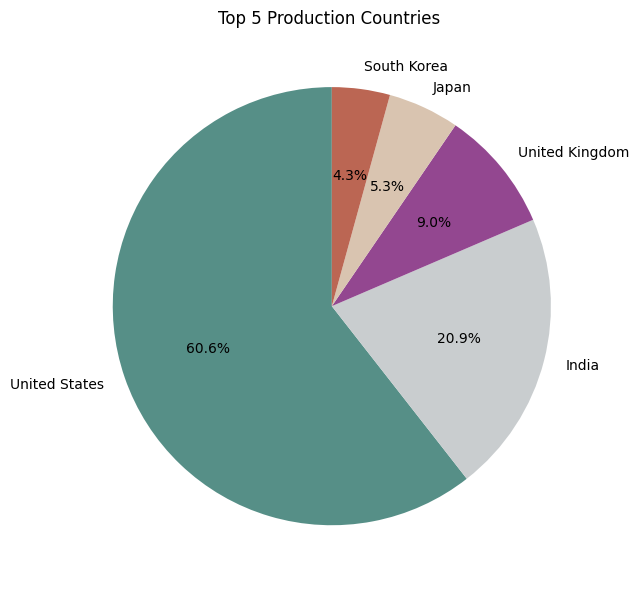

In [58]:
country_counts = netflix_df['country'].value_counts()

# after this it is showing the third largest production is belong to unknown that i handle in cleaning so showing this in the
# pie chart is awkward so we have drop this unknown

country_counts_without_unknown = country_counts.drop('unknown')   # this will drop the unkown country just to make the insight of pie chart more suitable
top_5 = country_counts_without_unknown.head(5)
plt.figure (figsize=(10,6))
plt.pie(top_5,labels=top_5.index, colors=[
    '#568F87','#C9CDCF','#934790','#D9C4B0','#BB6653'
],startangle=90,autopct='%1.1f%%')
plt.title("Top 5 Production Countries ")
plt.tight_layout()
plt.savefig('producitons_per_country.png')
plt.show()

---

Categorizing all the movies and the tv shows on the basis of there Genre 

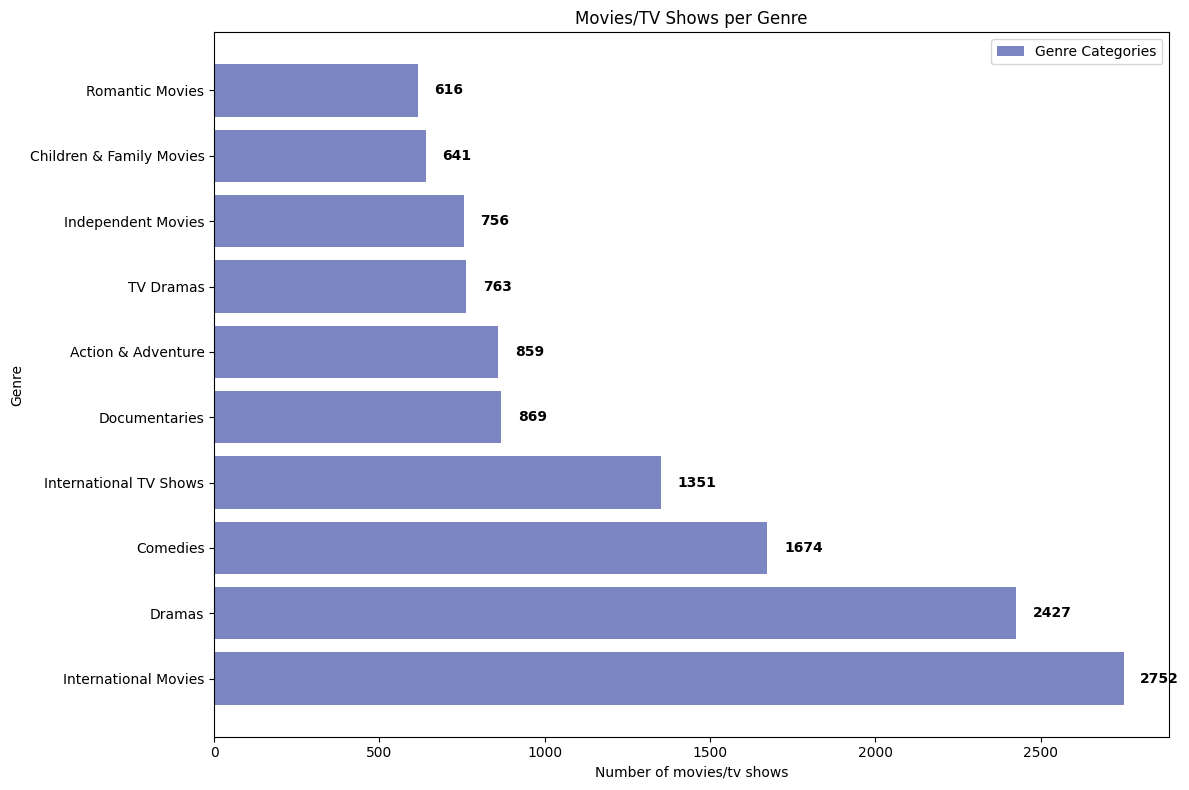

In [96]:
# splitting the Genre that is present in combine form in the listed_in column of the file 
all_genre = netflix_df['listed_in'].str.split(',').explode().str.strip()
top_10 = all_genre.value_counts().head(10)
plt.figure (figsize=(12,8))
plt.barh(top_10.index , top_10.values, color ='#7A85C1',label="Genre Categories")

# to add the text parallel to the bars of the bar chart 
for i , v in enumerate (top_10.values):
    plt.text(v+50 , i , str(v), va='center', fontweight= 'bold',color='black')

plt.title("Movies/TV Shows per Genre")
plt.ylabel('Genre')
plt.xlabel("Number of movies/tv shows")
plt.legend()
plt.tight_layout()
plt.savefig("Genre Categorization.png")
plt.show()

---

Monthly/Seasonal trend (using date_added) → Do they add more content in a particular month .                             For this first extracting of the month from the date_added column and then reindexing it and finding the number of counts of each month by value_counts ()  

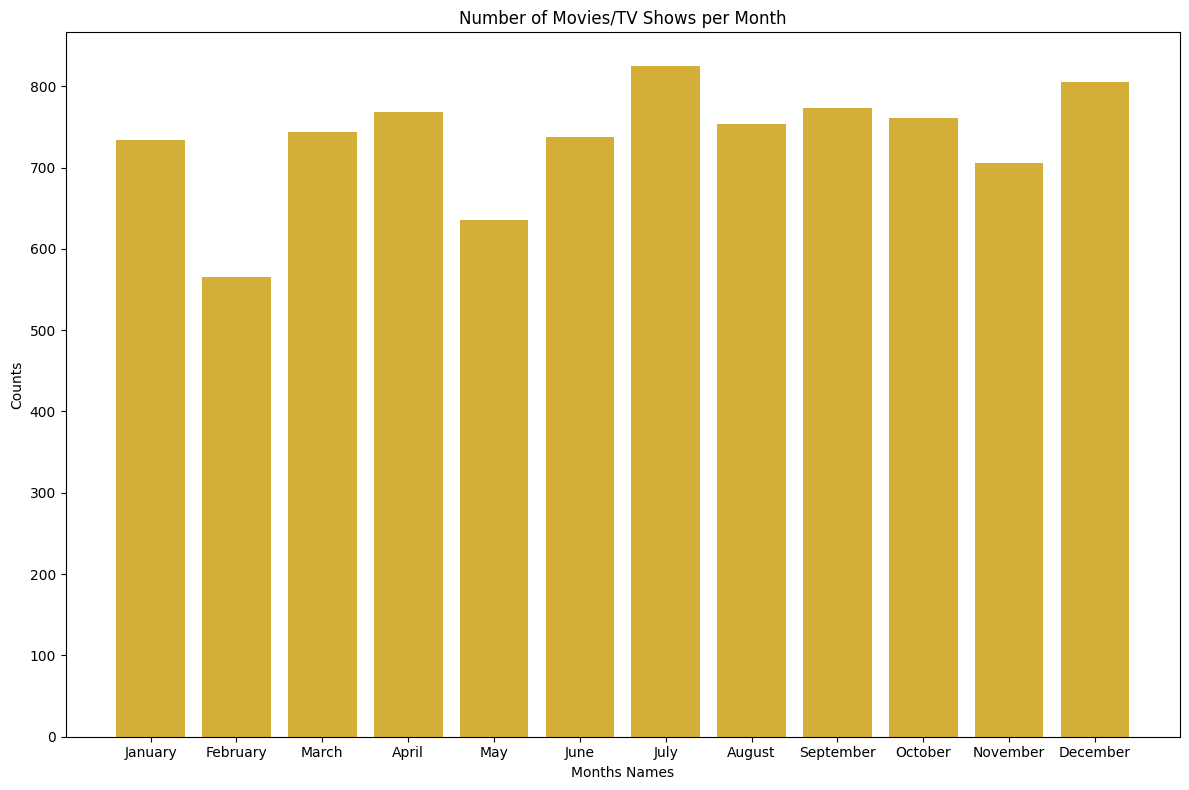

In [ ]:
import calendar 
netflix_df['months'] = netflix_df['date_added'].dt.month_name()
plt.figure(figsize=(12,8))
month = netflix_df['months'].value_counts().reindex(list(calendar.month_name[1:]))   # the parameters is for to conver the months in an order way
plt.bar(month.index, month.values, color='#D3AF37',label="Production per Month")
plt.title ("Number of Movies/TV Shows per Month")
plt.xlabel("Months Names")
plt.ylabel('Counts')
plt.tight_layout()
plt.savefig('Production per months.png')
plt.show()

---

Getting the season insight from the data , production of movies and tv shows per season 

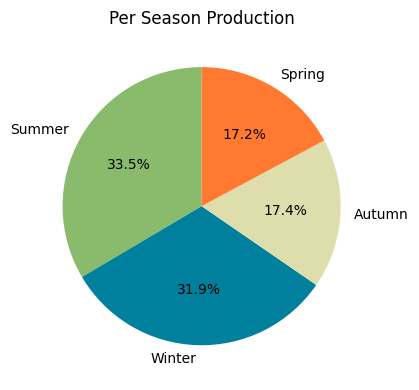

In [108]:
def get_season (month):
    if month in [11,12,1,2]:
        return "Winter"
    elif month in [3,4]:
        return 'Spring'
    elif month in [5,6,7,8]:
        return 'Summer'
    else :
        return 'Autumn'
    
netflix_df['months_no']= netflix_df['date_added'].dt.month   # this will get the months as int number from the date_added column
netflix_df['seasons'] = netflix_df['months_no'].apply (get_season)
seasons_count = netflix_df['seasons'].value_counts()
plt.figure (figsize=(6,4))
plt.pie (seasons_count.values, labels = seasons_count.index , colors=[
    '#8ABB6C','#00809D','#DDDEAB','#FF7A30'], startangle=90, autopct='%1.1f%%')
plt.title('Per Season Production')
plt.tight_layout()
plt.savefig('Seasonal production.png')
plt.show()